In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [9]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.drop(
    ["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Cabin", "Embarked"],
    axis="columns",
    inplace=True
)
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [11]:
target = df.Survived
inputs = df.drop("Survived", axis="columns")
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [12]:
inputs

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500
...,...,...,...,...
886,2,male,27.0,13.0000
887,1,female,19.0,30.0000
888,3,female,NaN,23.4500
889,1,male,26.0,30.0000


In [14]:
dummies = pd.get_dummies(inputs.Sex)
dummies.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [15]:
inputs = pd.concat([inputs, dummies], axis="columns")
inputs.head()

,Pclass,Sex,Age,Fare,female,male
0,3,male,22.0,7.2500,False,True
1,1,female,38.0,71.2833,True,False
2,3,female,26.0,7.9250,True,False
3,1,female,35.0,53.1000,True,False
4,3,male,35.0,8.0500,False,True


In [17]:
inputs.drop("Sex", axis="columns", inplace=True)
inputs.head()

,Pclass,Age,Fare,female,male
0,3,22.0,7.2500,False,True
1,1,38.0,71.2833,True,False
2,3,26.0,7.9250,True,False
3,1,35.0,53.1000,True,False
4,3,35.0,8.0500,False,True


In [18]:
inputs.columns[inputs.isna().any()]
inputs.Age = inputs.Age.fillna(inputs.Age.mean())
inputs.head(6)

,Pclass,Age,Fare,female,male
0,3,22.000000,7.2500,False,True
1,1,38.000000,71.2833,True,False
2,3,26.000000,7.9250,True,False
3,1,35.000000,53.1000,True,False
4,3,35.000000,8.0500,False,True
5,3,29.699118,8.4583,False,True


In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    inputs,
    target,
    test_size=0.3
)

In [20]:
x_train

,Pclass,Age,Fare,female,male
870,3,26.000000,7.8958,False,True
523,1,44.000000,57.9792,True,False
244,3,30.000000,7.2250,False,True
605,3,36.000000,15.5500,False,True
410,3,29.699118,7.8958,False,True
...,...,...,...,...,...
843,3,34.500000,6.4375,False,True
155,1,51.000000,61.3792,False,True
199,2,24.000000,13.0000,True,False
431,3,29.699118,16.1000,True,False


In [21]:
model = GaussianNB()
model.fit(x_train, y_train)
model.score(x_train, y_train)

0.7881219903691814

In [22]:
x_test[:10]

,Pclass,Age,Fare,female,male
741,1,36.000000,78.8500,False,True
639,3,29.699118,16.1000,False,True
425,3,29.699118,7.2500,False,True
315,3,26.000000,7.8542,True,False
345,2,24.000000,13.0000,True,False
667,3,29.699118,7.7750,False,True
626,2,57.000000,12.3500,False,True
671,1,31.000000,52.0000,False,True
159,3,29.699118,69.5500,False,True
343,2,25.000000,13.0000,False,True


In [23]:
y_test[:10]

741    0
639    0
425    0
315    1
345    1
667    0
626    0
671    0
159    0
343    0
Name: Survived, dtype: int64

In [ ]:
y_test

686     1
5241    0
4993    0
2485    0
2301    0
       ..
2233    0
4031    0
4429    0
3963    0
4518    0
Name: spam, Length: 1146, dtype: int64

In [26]:
predicted = model.predict(x_test[:10])
predicted

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

In [25]:
model.predict_proba(x_test[:10])

array([[0.78681276, 0.21318724],
       [0.99050322, 0.00949678],
       [0.99057002, 0.00942998],
       [0.04345136, 0.95654864],
       [0.01870114, 0.98129886],
       [0.99057685, 0.00942315],
       [0.975278  , 0.024722  ],
       [0.88691961, 0.11308039],
       [0.9764474 , 0.0235526 ],
       [0.97717179, 0.02282821]])

In [ ]:
cm = confusion_matrix(y_test[:10], predicted)
cm

array([[8, 0],
       [0, 2]])

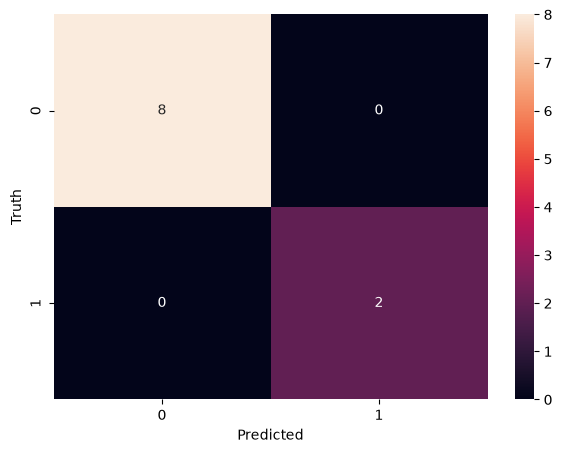

In [28]:
import seaborn as sns
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [30]:
print(classification_report(y_test[:10], predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

